<a href="https://colab.research.google.com/github/surkovaolga2005-png/python-ai-surkoa-olga/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Data Visualization — визуализация и анализ данных

**Цель:** построить графики по CSV-файлу из Wikidata и сделать краткие выводы по данным.

**Данные:**

- `countries_government_development.csv` — страны, форма правления, индекс человеческого развития, ВВП на душу населения и континент из Wikidata.
- `population.csv` — население стран по годам из Wikidata.

**Что мы делаем:**

1. Клонируем репозиторий GitHub в Colab.
2. Читаем CSV-файл через pandas.
3. Переименовываем столбцы.
4. Проверяем и очищаем данные.
5. Строим графики.
6. Делаем выводы по каждому графику.

In [ ]:
# удаляем старую копию репозитория, если она уже была загружена
!rm -rf python-ai-surkoa-olga

# клонируем репозиторий из github
!git clone https://github.com/surkovaolga2005-png/python-ai-surkoa-olga

Cloning into 'python-ai-surkoa-olga'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 384 (delta 156), reused 111 (delta 111), pack-reused 205 (from 2)
Receiving objects: 100% (384/384), 2.60 MiB | 17.07 MiB/s, done.
Resolving deltas: 100% (218/218), done.


In [ ]:
# подключаем библиотеки для работы с таблицами и графиками
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# читаем основной csv файл
file_path = "python-ai-surkoa-olga/data/countries_government_development.csv"

df = pd.read_csv(file_path)

df.head()

,country,countryLabel,governmentLabel,hdi,gdpPerCapita,continentLabel
0,http://www.wikidata.org/entity/Q139656941,Q139656941,монархия,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q408,Австралия,конституционная монархия,0.951,54348.23,Австралия и Океания
2,http://www.wikidata.org/entity/Q408,Австралия,федеративное государство,0.951,54348.23,Австралия и Океания
3,http://www.wikidata.org/entity/Q408,Австралия,представительная демократия,0.951,54348.23,Австралия и Океания
4,http://www.wikidata.org/entity/Q40,Австрия,республика,0.916,NaN,Европа


In [ ]:
# переименовываем столбцы основного файла
df = df.rename(columns={
    "country": "country_id",
    "countryLabel": "country",
    "governmentLabel": "form_of_government",
    "hdi": "human_development_index",
    "gdpPerCapita": "gdp_per_capita",
    "continentLabel": "continent"
})

# приводим числовые столбцы к числовому типу
df["human_development_index"] = pd.to_numeric(df["human_development_index"], errors="coerce")
df["gdp_per_capita"] = pd.to_numeric(df["gdp_per_capita"], errors="coerce")

df.head()

,country_id,country,form_of_government,human_development_index,gdp_per_capita,continent
0,http://www.wikidata.org/entity/Q139656941,Q139656941,монархия,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q408,Австралия,конституционная монархия,0.951,54348.23,Австралия и Океания
2,http://www.wikidata.org/entity/Q408,Австралия,федеративное государство,0.951,54348.23,Австралия и Океания
3,http://www.wikidata.org/entity/Q408,Австралия,представительная демократия,0.951,54348.23,Австралия и Океания
4,http://www.wikidata.org/entity/Q40,Австрия,республика,0.916,NaN,Европа


In [ ]:
# создаем таблицу без повторов стран
df_unique = df.drop_duplicates(subset=["country_id"])

# проверяем количество строк
print("строк в исходной таблице:", df.shape[0])
print("уникальных стран:", df_unique.shape[0])
print("количество удаленных дублей:", df.shape[0] - df_unique.shape[0])

строк в исходной таблице: 329
уникальных стран: 210
количество удаленных дублей: 119


In [ ]:
# проверяем заполненность optional полей
print("доля стран с известным hdi:", df_unique["human_development_index"].notna().mean().round(2))
print("доля стран с известным ввп на душу населения:", df_unique["gdp_per_capita"].notna().mean().round(2))
print("доля стран с известным континентом:", df_unique["continent"].notna().mean().round(2))

доля стран с известным hdi: 0.92
доля стран с известным ввп на душу населения: 0.04
доля стран с известным континентом: 0.99


In [ ]:
# читаем файл с населением по годам
population_path = "python-ai-surkoa-olga/data/population.csv"

population_df = pd.read_csv(population_path)

population_df.head()

,country,countryLabel,population,pointInTime,year
0,http://www.wikidata.org/entity/Q408,Австралия,22637127,2012-03-01T00:00:00Z,2012.0
1,http://www.wikidata.org/entity/Q408,Австралия,22920450,2012-12-01T00:00:00Z,2012.0
2,http://www.wikidata.org/entity/Q408,Австралия,22826041,2012-09-01T00:00:00Z,2012.0
3,http://www.wikidata.org/entity/Q408,Австралия,22723904,2012-06-01T00:00:00Z,2012.0
4,http://www.wikidata.org/entity/Q408,Австралия,23035199,2013-03-01T00:00:00Z,2013.0


In [ ]:
# переименовываем столбцы в таблице с населением
population_df = population_df.rename(columns={
    "country": "country_id",
    "countryLabel": "country",
    "population": "population",
    "pointInTime": "point_in_time",
    "year": "year"
})

# приводим население и год к числовому типу
population_df["population"] = pd.to_numeric(population_df["population"], errors="coerce")
population_df["year"] = pd.to_numeric(population_df["year"], errors="coerce")

population_df.head()

,country_id,country,population,point_in_time,year
0,http://www.wikidata.org/entity/Q408,Австралия,22637127,2012-03-01T00:00:00Z,2012.0
1,http://www.wikidata.org/entity/Q408,Австралия,22920450,2012-12-01T00:00:00Z,2012.0
2,http://www.wikidata.org/entity/Q408,Австралия,22826041,2012-09-01T00:00:00Z,2012.0
3,http://www.wikidata.org/entity/Q408,Австралия,22723904,2012-06-01T00:00:00Z,2012.0
4,http://www.wikidata.org/entity/Q408,Австралия,23035199,2013-03-01T00:00:00Z,2013.0


In [ ]:
# удаляем строки без года и населения
population_clean = population_df.dropna(subset=["year", "population"]).copy()

# переводим год в целое число
population_clean["year"] = population_clean["year"].astype(int)

population_clean.head()

,country_id,country,population,point_in_time,year
0,http://www.wikidata.org/entity/Q408,Австралия,22637127,2012-03-01T00:00:00Z,2012
1,http://www.wikidata.org/entity/Q408,Австралия,22920450,2012-12-01T00:00:00Z,2012
2,http://www.wikidata.org/entity/Q408,Австралия,22826041,2012-09-01T00:00:00Z,2012
3,http://www.wikidata.org/entity/Q408,Австралия,22723904,2012-06-01T00:00:00Z,2012
4,http://www.wikidata.org/entity/Q408,Австралия,23035199,2013-03-01T00:00:00Z,2013


In [ ]:
# агрегируем население по стране и году
pop_yearly = (
    population_clean
    .groupby(["country_id", "country", "year"], as_index=False)["population"]
    .max()
)

pop_yearly.head()

,country_id,country,year,population
0,http://www.wikidata.org/entity/Q1000,Габон,1960,498823
1,http://www.wikidata.org/entity/Q1000,Габон,1961,503762
2,http://www.wikidata.org/entity/Q1000,Габон,1962,509348
3,http://www.wikidata.org/entity/Q1000,Габон,1963,515762
4,http://www.wikidata.org/entity/Q1000,Габон,1964,523236


In [ ]:
# проверяем данные после агрегации
print("строк до агрегации:", population_clean.shape[0])
print("строк после агрегации:", pop_yearly.shape[0])
print("количество стран:", pop_yearly["country_id"].nunique())
print("минимальный год:", pop_yearly["year"].min())
print("максимальный год:", pop_yearly["year"].max())

строк до агрегации: 10220
строк после агрегации: 9872
количество стран: 207
минимальный год: 1605
максимальный год: 2026


In [ ]:
# считаем количество стран по континентам
continent_counts = (
    df_unique
    .dropna(subset=["continent"])
    ["continent"]
    .value_counts()
)

continent_counts

,count
continent,
Африка,55
Европа,51
Азия,46
Северная Америка,27
Южная Америка,12
Австралия и Океания,8
Океания,8


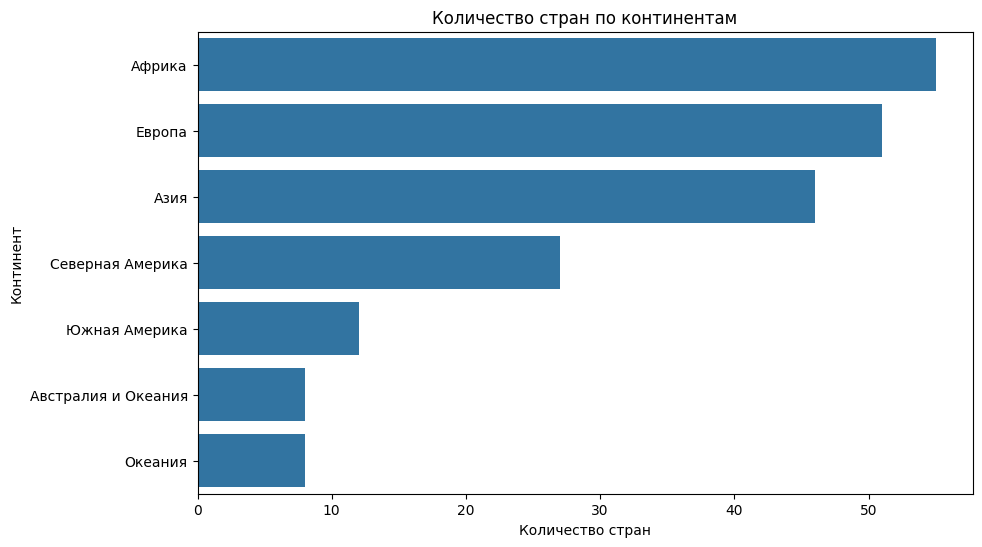

In [ ]:
# строим график количества стран по континентам
plt.figure(figsize=(10, 6))
sns.barplot(x=continent_counts.values, y=continent_counts.index)

plt.title("Количество стран по континентам")
plt.xlabel("Количество стран")
plt.ylabel("Континент")
plt.show()

На графике видно, сколько уникальных стран относится к каждому континенту. Для построения используется df_unique, поэтому страны с несколькими формами правления не считаются несколько раз.

In [ ]:
# оставляем строки с известным hdi
hdi_data = df_unique.dropna(subset=["human_development_index"])

hdi_data[["country", "human_development_index"]].head()

,country,human_development_index
1,Австралия,0.951
4,Австрия,0.916
7,Азербайджан,0.745
10,Албания,0.796
11,Алжир,0.745


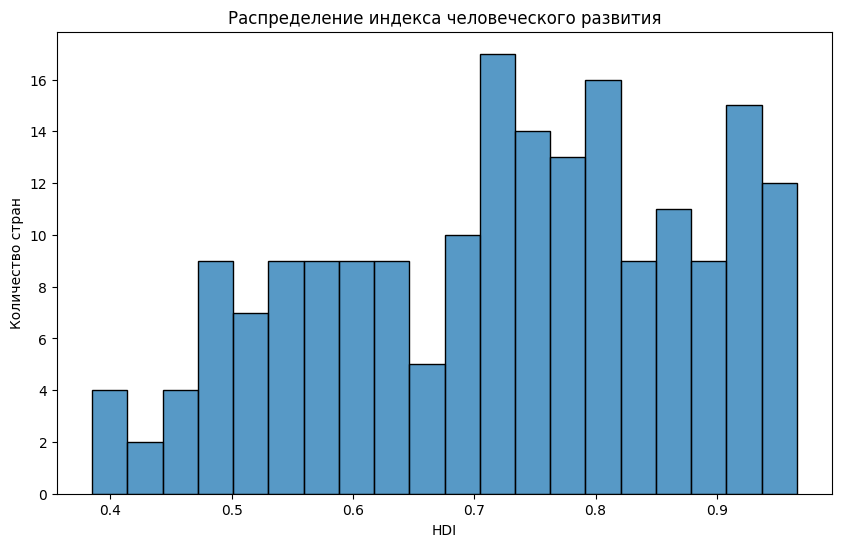

In [ ]:
# строим распределение индекса человеческого развития
plt.figure(figsize=(10, 6))
sns.histplot(hdi_data["human_development_index"], bins=20)

plt.title("Распределение индекса человеческого развития")
plt.xlabel("HDI")
plt.ylabel("Количество стран")
plt.show()

Большинство стран находится в средней и высокой зоне индекса человеческого развития. График построен только по странам, у которых значение HDI известно.

In [ ]:
# берем последнее известное значение населения для каждой страны
latest_population = (
    pop_yearly
    .sort_values(["country_id", "year"])
    .groupby("country_id", as_index=False)
    .tail(1)
)

top_population = latest_population.sort_values("population", ascending=False).head(10)

top_population[["country", "year", "population"]]

,country,year,population
1871,Китай,2025,1404890000
5614,Индия,2020,1326093247
4128,США,2024,340110988
3704,Индонезия,2021,275439000
8235,Пакистан,2021,223773700
1935,Бразилия,2025,213421037
1064,Нигерия,2021,211400708
8724,Бангладеш,2023,171466990
1956,Россия,2025,146119928
9370,Мексика,2024,132274416


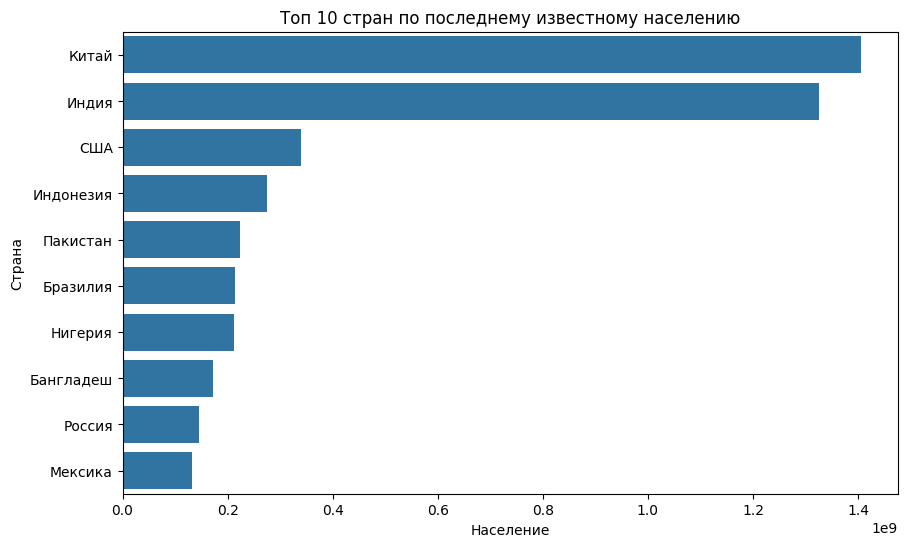

In [ ]:
# строим график стран с самым большим населением
plt.figure(figsize=(10, 6))
sns.barplot(data=top_population, x="population", y="country")

plt.title("Топ 10 стран по последнему известному населению")
plt.xlabel("Население")
plt.ylabel("Страна")
plt.show()

На графике показаны страны с самым большим последним известным значением населения. Для каждой страны использована только одна последняя запись, чтобы не смешивать разные годы.

In [ ]:
# выбираем несколько стран для временного графика
selected_countries = ["Австралия", "Австрия", "Китай", "Индия", "Россия"]

population_selected = pop_yearly[
    pop_yearly["country"].isin(selected_countries)
]

population_selected.head()

,country_id,country,year,population
1861,http://www.wikidata.org/entity/Q148,Китай,2010,1359755102
1862,http://www.wikidata.org/entity/Q148,Китай,2011,1367480264
1863,http://www.wikidata.org/entity/Q148,Китай,2012,1375198619
1864,http://www.wikidata.org/entity/Q148,Китай,2013,1382793212
1865,http://www.wikidata.org/entity/Q148,Китай,2014,1390110388


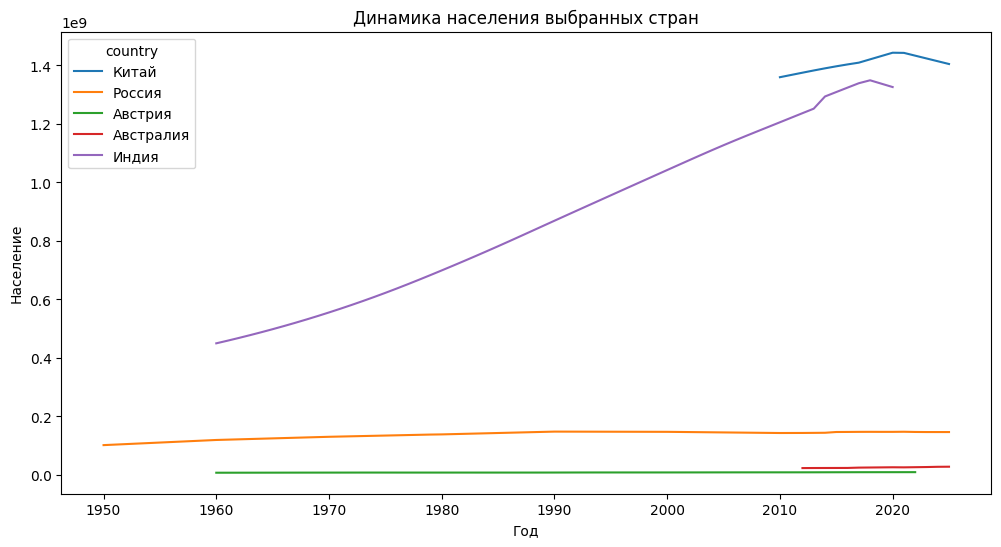

In [ ]:
# строим динамику населения по годам
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=population_selected,
    x="year",
    y="population",
    hue="country"
)

plt.title("Динамика населения выбранных стран")
plt.xlabel("Год")
plt.ylabel("Население")
plt.show()

На графике показана динамика населения выбранных стран по годам. Перед построением данные были агрегированы, поэтому для одной страны и одного года остается только одно значение.

In [ ]:
# оставляем страны с известными hdi и ввп
hdi_gdp_data = df_unique.dropna(
    subset=["human_development_index", "gdp_per_capita"]
)

print("количество стран для графика:", hdi_gdp_data.shape[0])

hdi_gdp_data[["country", "human_development_index", "gdp_per_capita"]].head()

количество стран для графика: 9


,country,human_development_index,gdp_per_capita
1,Австралия,0.951,54348.23
31,Барбадос,0.790,18798.00
46,Ботсвана,0.693,6710.99
63,Венгрия,0.846,37128.00
122,Испания,0.905,29993.06


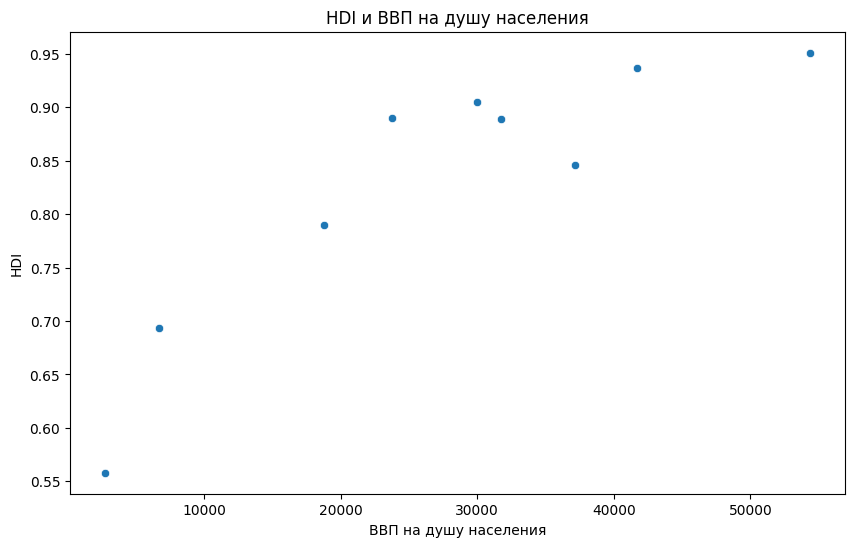

In [ ]:
# строим связь между hdi и ввп на душу населения
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=hdi_gdp_data,
    x="gdp_per_capita",
    y="human_development_index"
)

plt.title("HDI и ВВП на душу населения")
plt.xlabel("ВВП на душу населения")
plt.ylabel("HDI")
plt.show()

Этот график нужно интерпретировать осторожно, потому что ВВП на душу населения заполнен только у небольшой части стран. Поэтому он подходит скорее для демонстрации работы с данными, чем для сильного аналитического вывода.

## Общий вывод

В этом ноутбуке данные были заново загружены и очищены перед визуализацией. Для анализа стран использовалась таблица df_unique, где каждая страна учитывается один раз. Это нужно, чтобы страны с несколькими формами правления не искажали статистику.

Для данных о населении была создана таблица pop_yearly. В ней данные агрегированы по стране и году, поэтому для одной страны в одном году остается только одно значение населения.

Были построены графики по континентам, индексу человеческого развития, населению и связи HDI с ВВП на душу населения. Самое важное ограничение данных связано с тем, что показатель ВВП на душу населения заполнен слабо, поэтому выводы по нему нужно делать осторожно.